In [4]:
import sys
print(sys.executable)
print(sys.version)


c:\Users\dhira_5fqr2uc\anaconda3\envs\dr_env\python.exe
3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]


In [1]:
import torch
print(torch.__version__)


2.9.1+cpu


In [4]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split


In [5]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split


In [6]:
DATASET_PATH = "Datasets/Final_DR_Dataset"

classes = sorted(os.listdir(DATASET_PATH))
print("Classes:", classes)


Classes: ['0', '1', '2', '3', '4', 'APTOS', 'EyePACS', 'IDRiD']


In [7]:
# Training transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transforms
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [9]:
full_dataset = ImageFolder(root=DATASET_PATH, transform=train_transforms)

print("Total images:", len(full_dataset))
print("Class → Index:", full_dataset.class_to_idx)


Total images: 35853
Class → Index: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


In [10]:
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# Apply correct transforms
val_dataset.dataset.transform = test_transforms
test_dataset.dataset.transform = test_transforms

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))


Train: 25097
Validation: 5377
Test: 5379


In [11]:
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0416646].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0371337].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0130792].


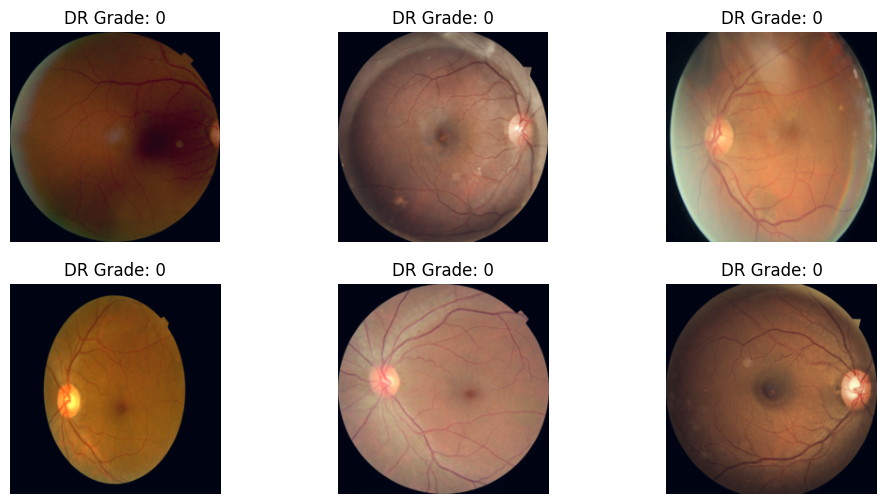

In [12]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(6):
    img = images[i].permute(1, 2, 0)
    img = img * 0.229 + 0.485  # de-normalize
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"DR Grade: {labels[i].item()}")
    plt.axis("off")

plt.show()


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models


: 